# Autoencoding and Self-Supervision

In [2]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [3]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


 dl_utils loaded
Device available: cuda


## Implementing a *Principal Component Analysis* (PCA) as an Autoencoder
We define the network function: $$f(x) = xWW^{T}$$

In [4]:
# Define constants for features
D = 28*28     # Values in the input
n = 2         # Hidden layers size 
C = 1         # Number of channles
classes = 10  # Number of classes

In [5]:
# View class to conver the image shape
class View(nn.Module):
    def __init__(self, *shape):
        super(View, self).__init__()
        self.shape = shape
    def forward(self, input):
        return input.view(*self.shape) 

In [6]:
# Define the TransposeLinear class
class TransposeLinear(nn.Module):   # Class extens nn.Module and all PyTorch layers extend this
    def __init__(self, linearLayer, bias=True):
        """ 
        LinearLayer: is the layer that we want to use the transpose of to produce the ouput of this layer. 
                     The linea layer represents W, and this layer represents W^T.
        bias: if True, creates a new bias term b that is learned separately from what is in linearLayer. If
              false no bias vector is used.
        """

        super().__init__()
        self.weight = linearLayer.weight     # Creates the new variable weight to store a reference to original weight
        if bias:
            self.bias = nn.Parameter(torch.Tensor(linearLayer.weight.shape[1])) # Creates new bias vector
        else:
            self.register_parameter('bias', None)
        
    def forward(self, x):
                return F.linear(x, self.weight.t(), self.bias)
    

In [8]:
# Implement PCA

# Define the linear layer
linearLayer = nn.Linear(D, n, bias=False)

# Encoder flattens and use the linear layer
pca_encoder = nn.Sequential(
    nn.Flatten(),
    linearLayer
    )

    # Decoder uses the TransposeLienar layer.
pca_decoder = nn.Sequential(
    TransposeLinear(linearLayer, bias=False), 
    View(-1, 1, 28, 28)   # Shapes data back to original form
    )

    # Defineas a final PCA model with encoder, decoder
pca_model = nn.Sequential(
    pca_encoder,
    pca_decoder
    )

    # Add the constraint
nn.init.orthogonal_(linearLayer.weight)

    #Original Loss function
mse_loss = nn.MSELoss()

In [9]:
# The PCA loss function
def mseWithOrthoLoss(x, y):
    W = linearLayer.weight   
    I = torch.eye(W.shape[0]).to(device) # Identity matrix target for regularization

    normal_loss = mse_loss(x, y)  # Computes original loss
    regularization_loss = 0.1*mse_loss(torch.mm(W, W.t()), I) # computes regularizer penalty
          
    return normal_loss + regularization_loss 

### Implementing PCA with PyTorch
Crate a Wrapper for the MNIST dataset. It will transform (x, y) to (x , x)

In [11]:
# Add the class AtoEncodeDataset
class AutoEncodeDataset(Dataset):
    """  
    Takes a dataset with (x, y) and convets to (x, x)
    """

    def __init__(self, dataset):
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        x, y = self.dataset.__getitem__(idx)
        return x, x

In [12]:
# Load the MNIST dataset and transform it into (x, x)
train_data = (AutoEncodeDataset(torchvision.datasets.MNIST("./data/Autoencoder", train=True, 
                                                           transform=transforms.ToTensor(), 
                                                           download=True))
)

test_data_xy = torchvision.datasets.MNIST("./data/Autoencoder", train=True,
                                          transform=transforms.ToTensor(),
                                          download=True
)

test_data_xx = AutoEncodeDataset(test_data_xy)



In [13]:
# Data loaders
train_loader = DataLoader(train_data, 
                          batch_size=128, 
                          shuffle=True,
                          num_workers=4,
                          pin_memory=True,
                          persistent_workers=True,
                          drop_last=True
)

test_loader = DataLoader(test_data_xx, 
                        batch_size=128*2,
                        shuffle=False,
                        num_workers=4,
                        persistent_workers=True,
                        pin_memory=True
)

In [12]:
# Train the network
train_network_EZA(pca_model,
                  mseWithOrthoLoss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

/home/efrain/anaconda3/envs/pytorch-gpu/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Epoch: 100%|██████████| 30/30 [02:55<00:00,  5.85s/it]


,epoch,total time,train loss,test loss
0,0,2.464533,0.064086,0.058442
1,1,2.342345,0.058126,0.057925
2,2,2.752505,0.057904,0.057908
3,3,3.487231,0.057887,0.057915
4,4,2.966142,0.057893,0.057879
5,5,3.242669,0.057894,0.057878
6,6,2.901089,0.057890,0.057881
7,7,2.947281,0.057888,0.057882
8,8,3.186225,0.057893,0.057885
9,9,3.239151,0.057883,0.057904


### Visualizing PCA results

In [16]:
def encode_batch(encoder, dataset_to_encode):
    """ 
    encoder: The PyTorch network that takes in a dataset and converts it to a new dimension
    dataset_to_encode: a PyTorch `dataset` object that we want to convert

    Returns a tuple (projected, labels) where `projected` is the encoded version of the dataset,
    and `labels` are the original labels provided by the `dataset_to_encode`.
    """

    projected = []
    labels = []     # The spaces to store the results
    encoder = encoder.eval()  # Switches to eval mode
    encoder = encoder.cpu()   # Moves to CPU for simplicity

    with torch.no_grad():  # No training
        for x, y in DataLoader(dataset_to_encode, batch_size=128):
            z = encoder(x.cpu())    # encodes the original data
            projected.append(z.numpy())   # Stores the encoded version and label
            labels.append(y.cpu().numpy().ravel())  
    
    projected = np.vstack(projected) # Turns the result into single large Numpy arrays
    labels = np.hstack(labels)
    return projected, labels

In [14]:
# Project the data
projected, labels = encode_batch(pca_encoder, test_data_xy)

<Axes: >

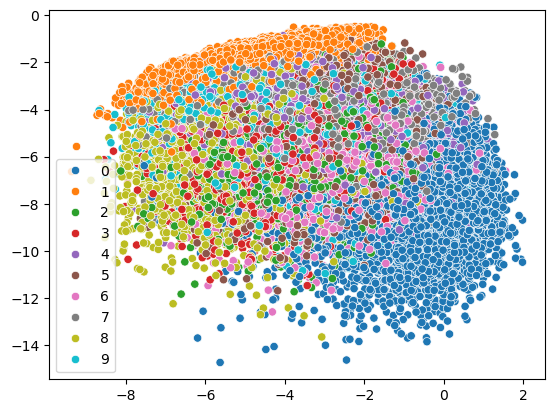

In [15]:
# Plots the results
sns.scatterplot(x=projected[:,0], y=projected[:,1], 
                hue=[str(i) for i in labels], 
                hue_order=[str(j) for j in range(10)],
                legend='full')


In [20]:
# Create a function to plot the result correlations x vs decoded x
def showEncodeDecode(encode_decode, x):
    """ 
    encode_decode: the PyTorch Module that does the encoding and decoding steps at once
    x: the input to plot as is, and after encoding and decoding it
    """

    encode_decode = encode_decode.eval()  # Eval mode
    encode_decode = encode_decode.cpu() #  use the CPU

    with torch.no_grad():  # Not training mode
        x_recon = encode_decode(x.cpu())
    f, axarr = plt.subplots(1,2)
    axarr[0].imshow(x.numpy()[0,:])
    axarr[1].imshow(x_recon.numpy()[0,0,:])

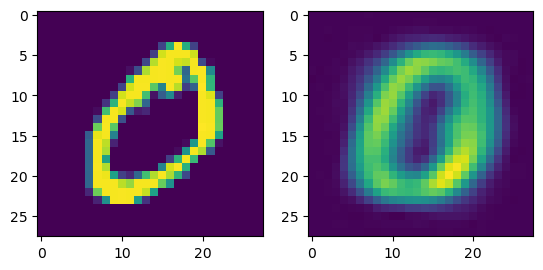

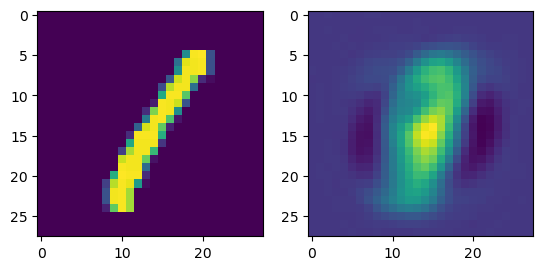

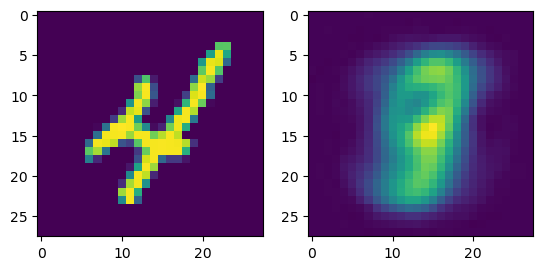

In [19]:
# Use the function to plot the results for encoder/decoder
showEncodeDecode(pca_model, test_data_xy[1][0])
showEncodeDecode(pca_model, test_data_xy[3][0])
showEncodeDecode(pca_model, test_data_xy[9][0])

### A simple nonlinear PCA (Autoencoder)

In [15]:
pca_nonlinear_encode = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.Tanh(),   # Nonlinearity to make it a nonlinear autoencoder
)

pca_nonlinear_decoder = nn.Sequential(
    nn.Linear(n, D),
    View(-1, 1, 28, 28)
)

pca_nonlinear = nn.Sequential(
    pca_nonlinear_encode,
    pca_nonlinear_decoder
)

In [21]:
# Train the nonlinear autoencoder
train_network_EZA(pca_nonlinear,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [02:49<00:00,  5.66s/it]


,epoch,total time,train loss,test loss
0,0,2.294269,0.131442,0.068645
1,1,2.295506,0.066225,0.065486
2,2,2.306328,0.065156,0.064787
3,3,2.637192,0.064323,0.063782
4,4,3.140934,0.063083,0.062261
5,5,3.041318,0.061282,0.060244
6,6,3.040559,0.059338,0.058533
7,7,3.116113,0.057986,0.057535
8,8,3.049120,0.057227,0.056962
9,9,3.056099,0.056790,0.056631


<Axes: >

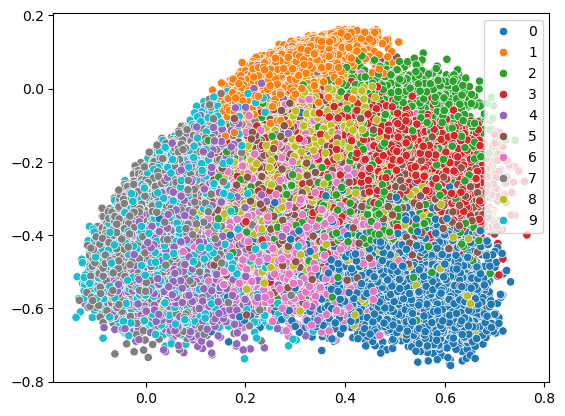

In [22]:
projected_nonlinear, labels_nonlinear = encode_batch(pca_nonlinear_encode, test_data_xy)
sns.scatterplot(x=projected_nonlinear[:,0], y=projected_nonlinear[:,1], 
                hue=[str(i) for i in labels_nonlinear], 
                hue_order=[str(j) for j in range(10)],
                legend='full')

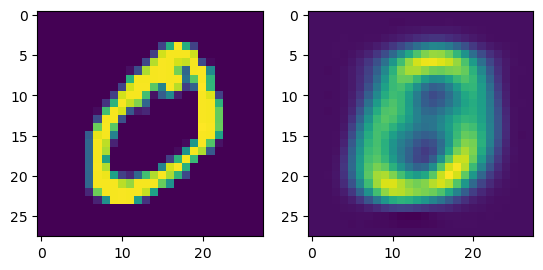

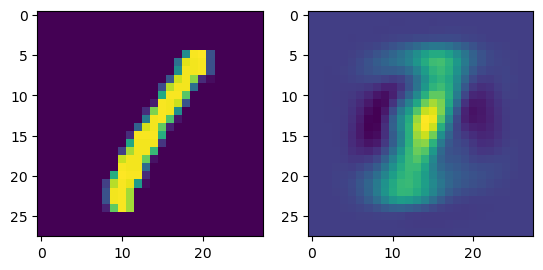

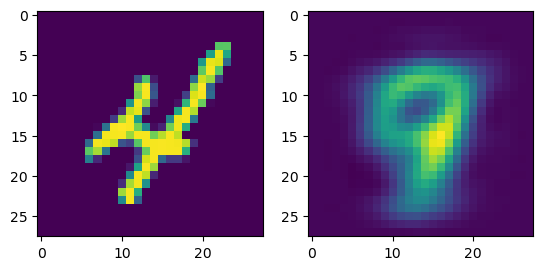

In [23]:
showEncodeDecode(pca_nonlinear, test_data_xy[1][0])
showEncodeDecode(pca_nonlinear, test_data_xy[3][0])
showEncodeDecode(pca_nonlinear, test_data_xy[9][0])

## Designing Autoencoding Neural Networks
**Autoencoding networks** can be use for *outlier detection*.\
To construct autoencoder network, the usual approach is to make a symmetric architecture between the encoder\
and autoencoder, but the do not need to be symetrical.

We use the helper function `getLayer` to create a single hidden layer.

In [9]:
def getLayer(in_size, out_size):
    """ 
    in_size: number of neurons/features in the input
    out_size: the size of the output of the layer
    bias: if True, creates a bias term for this layer. If False, no bias is used.
    """

    return nn.Sequential(
        nn.Linear(in_size, out_size),
        nn.BatchNorm1d(out_size),  # Normalizes the output of the linear layer
        nn.ReLU()
    )

In [13]:
# Define the encoder and decoder for a deeper autoencoder
auto_encoder = nn.Sequential(
    nn.Flatten(),
    getLayer(D, D//2),
    getLayer(D//2, D//3),
    getLayer(D//3, D//4),
    nn.Linear(D//4, n)
)

auto_decoder = nn.Sequential(
    getLayer(n, D//4),
    getLayer(D//4, D//3),
    getLayer(D//3, D//2),
    nn.Linear(D//2, D),
    View(-1, 1, 28, 28)
)

auto_encode_decode = nn.Sequential(
    auto_encoder,
    auto_decoder
)
    #Original Loss function
mse_loss = nn.MSELoss()

In [14]:
# Train the deeper autoencoder
train_network_EZA(auto_encode_decode,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [03:19<00:00,  6.64s/it]


,epoch,total time,train loss,test loss
0,0,3.664072,0.049596,0.043055
1,1,3.033066,0.043197,0.041211
2,2,3.820308,0.041999,0.040998
3,3,3.854830,0.041156,0.039776
4,4,3.843635,0.040625,0.039143
5,5,3.841911,0.040106,0.038361
6,6,3.814963,0.039813,0.038198
7,7,3.830803,0.039385,0.037676
8,8,3.847377,0.039021,0.038057
9,9,3.822972,0.038881,0.037184


<Axes: >

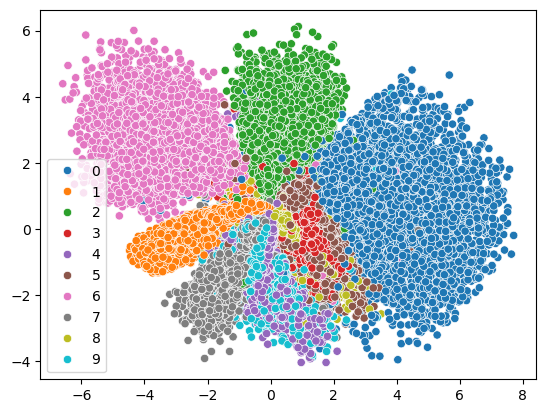

In [17]:
# Visualize the results for the deeper autoencoder
projected, labels = encode_batch(auto_encoder, test_data_xy)
sns.scatterplot(x=projected[:,0], y=projected[:,1], 
                hue=[str(i) for i in labels], 
                hue_order=[str(j) for j in range(10)],
                legend='full')

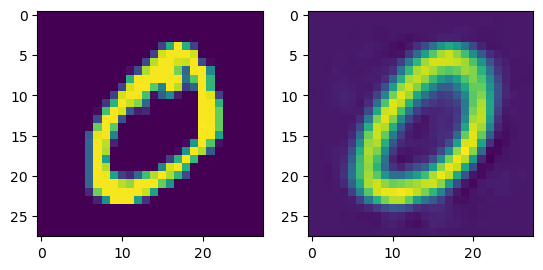

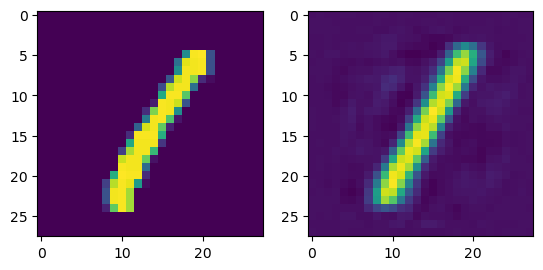

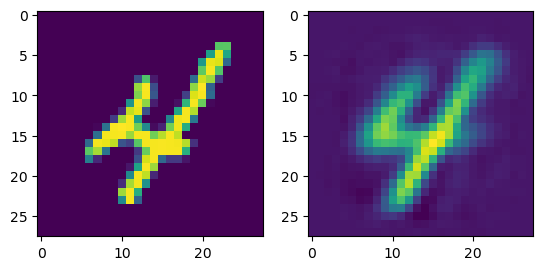

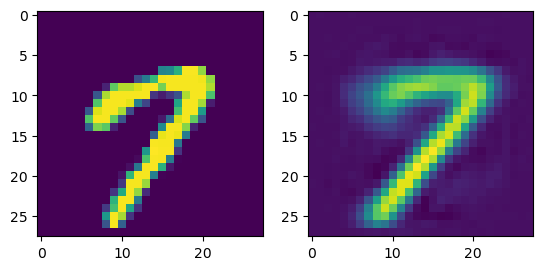

In [20]:
# Lood at examples of the deeper autoencoder
showEncodeDecode(auto_encode_decode, test_data_xy[1][0])
showEncodeDecode(auto_encode_decode, test_data_xy[3][0])
showEncodeDecode(auto_encode_decode, test_data_xy[9][0])
showEncodeDecode(auto_encode_decode, test_data_xy[15][0])

#  Bigger Autoencoders
Making the target size *larger* than the original

In [21]:
# Making a bigger autoencoder that increases D
auto_encoder_big = nn.Sequential(
    nn.Flatten(),
    getLayer(D, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D*2)
)

auto_decoder_big = nn.Sequential(
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D),
    View(-1, 1, 28, 28)
)
auto_encode_decode_big = nn.Sequential(
    auto_encoder_big,
    auto_decoder_big
)

In [ ]:
# Train the bigger autoencoder
train_network_EZA(auto_encode_decode_big,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [03:38<00:00,  7.27s/it]


,epoch,total time,train loss,test loss
0,0,3.961244,0.023837,0.014205
1,1,3.874910,0.012748,0.010602
2,2,4.566027,0.010586,0.008672
3,3,4.484287,0.009033,0.007771
4,4,4.502362,0.008362,0.007425
5,5,4.654069,0.007840,0.006956
6,6,4.504126,0.007546,0.006212
7,7,4.464123,0.007182,0.006457
8,8,4.551373,0.006661,0.005521
9,9,4.481148,0.006857,0.005879


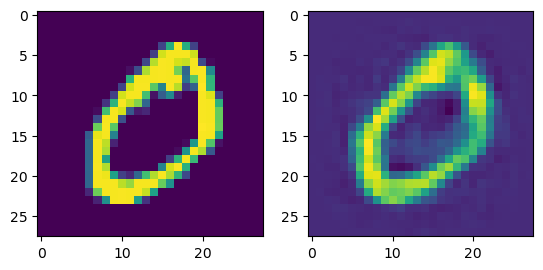

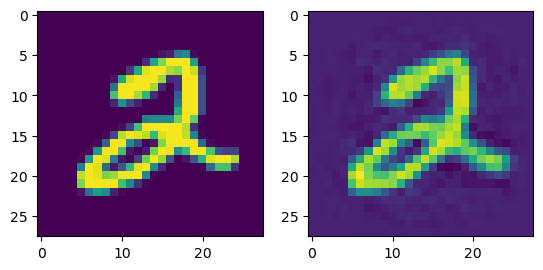

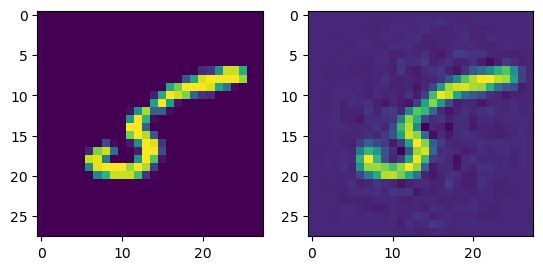

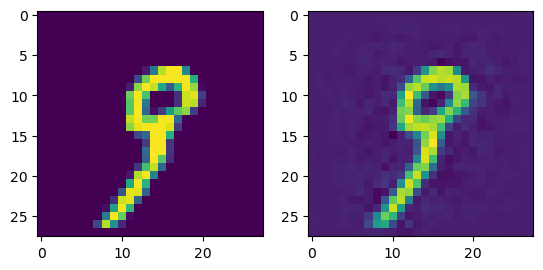

In [23]:
# Test results for the bigger autoencoder
showEncodeDecode(auto_encode_decode_big, test_data_xy[1][0])
showEncodeDecode(auto_encode_decode_big, test_data_xy[5][0])
showEncodeDecode(auto_encode_decode_big, test_data_xy[11][0])
showEncodeDecode(auto_encode_decode_big, test_data_xy[19][0])

### Robustness to noise of the autoencoder 
Test if a autoencoder with $D' = 2$ is better to $D' = 2*D$

In [17]:
# Create a function to add noise to the data and test the denoising capabilities of the autoencoder
normal = torch.distributions.Normal(0, 0.5) # Normal distribution with mean 0 and std 0.5

def addNoise(x, device='cpu'):
    """ 
    x: the input data to which we want to add noise
    device: the device to perform the operation on (default is 'cpu')
    """

    return x + normal.sample(sample_shape=torch.Size(x.shape)).to(device)

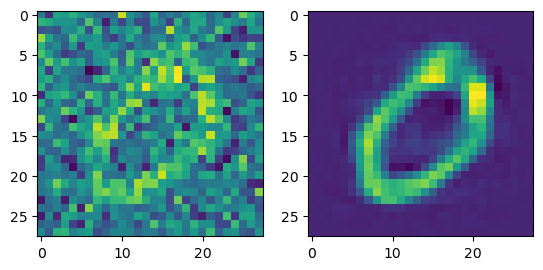

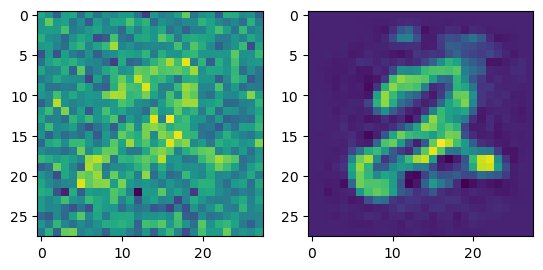

In [ ]:
# Visulize the noisy data with the bigger autoencoder
showEncodeDecode(auto_encode_decode_big, addNoise(test_data_xy[1][0]))
showEncodeDecode(auto_encode_decode_big, addNoise(test_data_xy[5][0]))

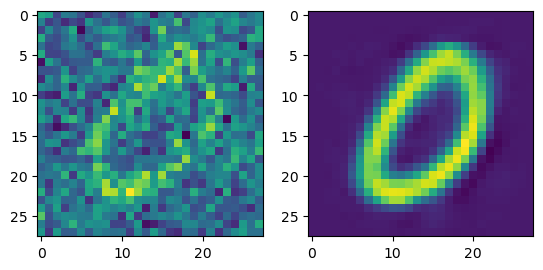

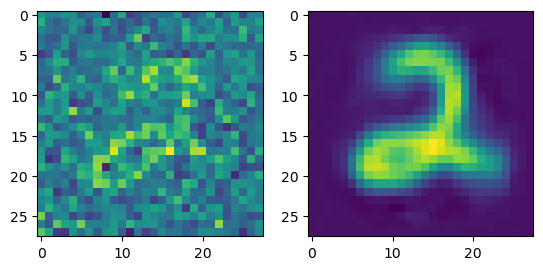

In [31]:
# Visulize the noisy data with the smaller autoencoder
showEncodeDecode(auto_encode_decode, addNoise(test_data_xy[1][0]))
showEncodeDecode(auto_encode_decode, addNoise(test_data_xy[5][0]))

**The smaller autoencoer is more robust**

## Denoising Autoencoders
A denoising autoencoder adds noise to the encoder's input while still expecting the decoder to produce a clean image.
### Denoising with Gaussian noise
We add a new layer at the beginning of the encoder subnetwork to add nois to the input ***only when we are training*** the `auto_encoder_big`.

In [7]:
# Add a class to add gausian noise to the data
class AdditiveGaussianNoise(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        if self.training:  # Only add noise during training
            return addNoise(x, device=device)
        else:
            return x

In [14]:
dnauto_encoder_big = nn.Sequential(
    nn.Flatten(),
    AdditiveGaussianNoise(),  # Adds noise to the data
    getLayer(D, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D*2)
)

dnauto_decoder_big = nn.Sequential(
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    getLayer(D*2, D*2),
    nn.Linear(D*2, D),
    View(-1, 1, 28, 28)
)

dnauto_encode_decode_big = nn.Sequential(
    dnauto_encoder_big,
    dnauto_decoder_big
)

In [18]:
    #Original Loss function
mse_loss = nn.MSELoss()

train_network_EZA(dnauto_encode_decode_big,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [04:01<00:00,  8.05s/it]


,epoch,total time,train loss,test loss
0,0,5.311294,0.032298,0.018989
1,1,4.539470,0.020999,0.014797
2,2,5.424820,0.018715,0.013772
3,3,5.260666,0.017750,0.012816
4,4,5.190572,0.016619,0.011748
5,5,5.489776,0.015931,0.011427
6,6,5.176247,0.015356,0.010973
7,7,5.143375,0.015035,0.010424
8,8,5.437262,0.014556,0.009900
9,9,5.132884,0.014143,0.009352


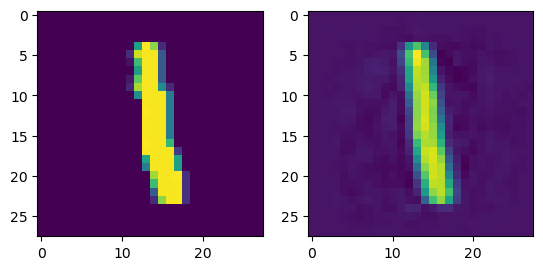

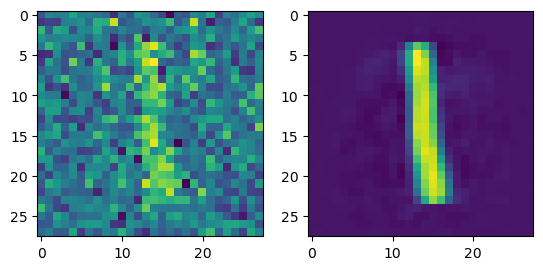

In [22]:
# compare the results of the denoising autoencoder with the regular autoencoder
showEncodeDecode(dnauto_encode_decode_big, test_data_xy[6][0])
showEncodeDecode(dnauto_encode_decode_big, addNoise(test_data_xy[6][0]))

### Denoising with Dropout
Dropout: with some probability $p$, zero out any given feature value.\
Dropout with $p = 20$%

In [23]:
dnauto_encoder_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2), 
    nn.Dropout(),
    nn.Linear(D*2, D*2)
)

dnauto_decoder_dropout = nn.Sequential(
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    getLayer(D*2, D*2),
    nn.Dropout(0.2),  # 20% of the data is dropped out
    nn.Linear(D*2, D),
    View(-1, 1, 28, 28)
)

dnauto_encode_decode_dropout = nn.Sequential(
    dnauto_encoder_dropout,
    dnauto_decoder_dropout
)

In [24]:
train_network_EZA(dnauto_encode_decode_dropout,
                  mse_loss,
                  train_loader,
                  test_loader=test_loader,
                  epochs=30,
                  device=device
)

Epoch: 100%|██████████| 30/30 [03:37<00:00,  7.25s/it]


,epoch,total time,train loss,test loss
0,0,4.056163,0.041746,0.022992
1,1,3.986459,0.025993,0.017808
2,2,4.551448,0.022354,0.015706
3,3,4.622712,0.021037,0.014500
4,4,4.584042,0.019702,0.013712
5,5,4.599373,0.018754,0.012285
6,6,4.525416,0.018007,0.012023
7,7,4.543502,0.017765,0.011916
8,8,4.591442,0.017216,0.011707
9,9,4.576190,0.019690,0.011253


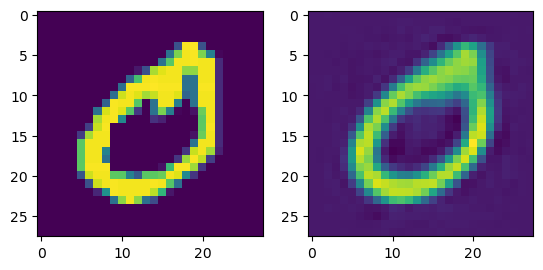

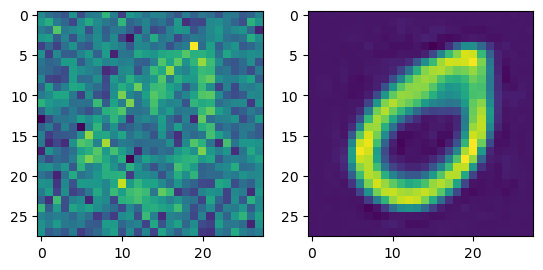

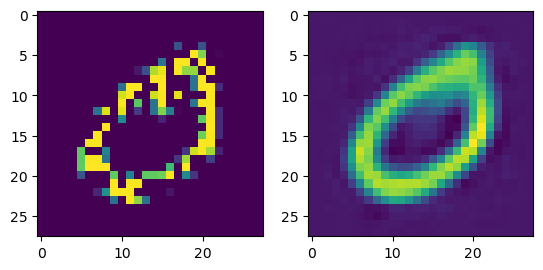

In [26]:
# See results and compare 
showEncodeDecode(dnauto_encode_decode_dropout, test_data_xy[21][0])
showEncodeDecode(dnauto_encode_decode_dropout, addNoise(test_data_xy[21][0]))
showEncodeDecode(dnauto_encode_decode_dropout, nn.Dropout()(test_data_xy[21][0]))